In [26]:
import pandas as pd
import shutil
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [13]:
shutil.unpack_archive("/content/homework.zip", "/content/homework")

# SVM з сирими даними

### Підготовка даних


In [14]:
shapes = set()
X = []
y = []
classes = os.listdir("/content/homework/data")

for activity in classes:
    folder_path = f"/content/homework/data/{activity}"

    files = [
        file for file in os.listdir(folder_path)
        if file.endswith(".csv")
    ]

    print(f"{activity}: {len(files)}")

    for file in files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        features = df.to_numpy().flatten()
        X.append(features)
        y.append(activity)
        shapes.add(df.shape)

print(shapes)
X = np.array(X)
y = np.array(y)
print(X.shape)
print(y.shape)

walking: 1850
idle: 1039
running: 3408
stairs: 165
{(30, 3)}
(6462, 90)
(6462,)


### Розподіл на train та test



In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

(5169, 90)
(1293, 90)
(5169,)
(1293,)


### Навчання моделі та передбачення

In [16]:
svm_model = SVC()

svm_model.fit(X_train_scaled, y_train)

y_pred_svm = svm_model.predict(X_test_scaled)

### Метрики

In [17]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       208
     running       1.00      1.00      1.00       682
      stairs       0.94      0.45      0.61        33
     walking       0.95      1.00      0.97       370

    accuracy                           0.99      1293
   macro avg       0.97      0.86      0.90      1293
weighted avg       0.99      0.99      0.98      1293



# SVM і time domain features

### Підготовка даних

In [18]:
time_features_list = []
y_time = []
classes = os.listdir("/content/homework/data")

for activity in classes:
    folder_path = f"/content/homework/data/{activity}"

    files = [
        file for file in os.listdir(folder_path)
        if file.endswith(".csv")
    ]

    for file in files:
        file_path = os.path.join(folder_path, file)
        df = pd.read_csv(file_path)
        time_features = {}
        for column in df.columns:
          time_features[f"{column}_mean"] = df[column].mean()
          time_features[f"{column}_std"] = df[column].std()
          time_features[f"{column}_min"] = df[column].min()
          time_features[f"{column}_max"] = df[column].max()
          time_features[f"{column}_median"] = df[column].median()
        time_features_list.append(time_features)
        y_time.append(activity)
# print(time_features_list)
# print(y_time)
X_time = pd.DataFrame(time_features_list)
print(X_time.head())
print(X_time.shape)

   accelerometer_X_mean  accelerometer_X_std  accelerometer_X_min  \
0             -4.652413             4.014018           -15.088259   
1             -4.011245             4.982659           -16.883911   
2             -4.334622             4.057019           -16.333244   
3             -3.192269             3.412089           -11.209652   
4             -3.338475             3.665210           -11.894394   

   accelerometer_X_max  accelerometer_X_median  accelerometer_Y_mean  \
0             4.141969               -3.383007             -9.203471   
1             2.576161               -2.676718            -10.116619   
2             0.766145               -3.102886             -9.324139   
3             2.207454               -2.552219             -8.499416   
4             1.106121               -1.951275             -9.874326   

   accelerometer_Y_std  accelerometer_Y_min  accelerometer_Y_max  \
0             4.964236           -17.980455             6.928820   
1             5.

### Розподіл на train і test

In [19]:
X_time_train, X_time_test, y_time_train, y_time_test = train_test_split(
    X_time,
    y_time,
    test_size=0.2,
    random_state=42,
    stratify=y_time
)
print(X_time_train.shape)
print(X_time_test.shape)
print(len(y_time_train))
print(len(y_time_test))

scaler_time = StandardScaler()
X_time_train_scaled = scaler_time.fit_transform(X_time_train)
X_time_test_scaled = scaler_time.transform(X_time_test)

(5169, 15)
(1293, 15)
5169
1293


### Навчання моделі та передбачення

In [20]:
svm_time_model = SVC()
svm_time_model.fit(X_time_train_scaled, y_time_train)
y_pred_svm_time = svm_time_model.predict(X_time_test_scaled)

### Метрики

In [21]:
print(classification_report(y_time_test, y_pred_svm_time))

              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       208
     running       1.00      1.00      1.00       682
      stairs       0.92      0.70      0.79        33
     walking       0.97      0.99      0.98       370

    accuracy                           0.99      1293
   macro avg       0.97      0.92      0.94      1293
weighted avg       0.99      0.99      0.99      1293



# Random Forest + сирі дані

### Навчання моделі та прогноз

In [22]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

### Метрики

In [23]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       208
     running       1.00      1.00      1.00       682
      stairs       1.00      0.06      0.11        33
     walking       0.92      1.00      0.96       370

    accuracy                           0.98      1293
   macro avg       0.98      0.77      0.77      1293
weighted avg       0.98      0.98      0.97      1293



# Random Forest + time-domain features

### Навчання моделі та прогноз

In [24]:
rf_time_model = RandomForestClassifier(random_state=42)
rf_time_model.fit(X_time_train, y_time_train)

y_pred_rf_time = rf_time_model.predict(X_time_test)

### Метрики

In [25]:
print(classification_report(y_time_test, y_pred_rf_time))

              precision    recall  f1-score   support

        idle       1.00      1.00      1.00       208
     running       1.00      1.00      1.00       682
      stairs       1.00      0.97      0.98        33
     walking       1.00      1.00      1.00       370

    accuracy                           1.00      1293
   macro avg       1.00      0.99      1.00      1293
weighted avg       1.00      1.00      1.00      1293



# Аналіз

### Random Forest - Raw Features

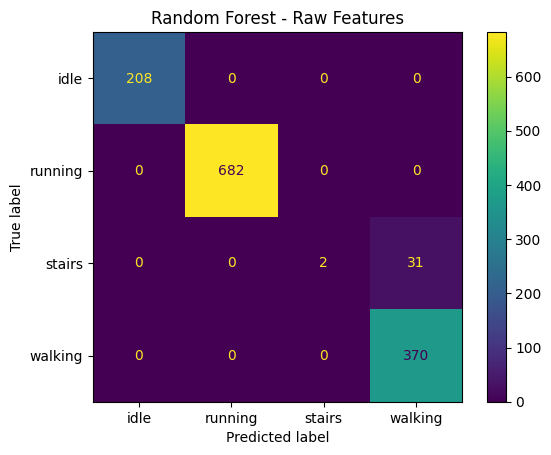

In [27]:
cm_rf_raw = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_raw,
    display_labels=rf_model.classes_
)

disp.plot()
plt.title("Random Forest - Raw Features")
plt.show()

### Random Forest - Time-Domain Features

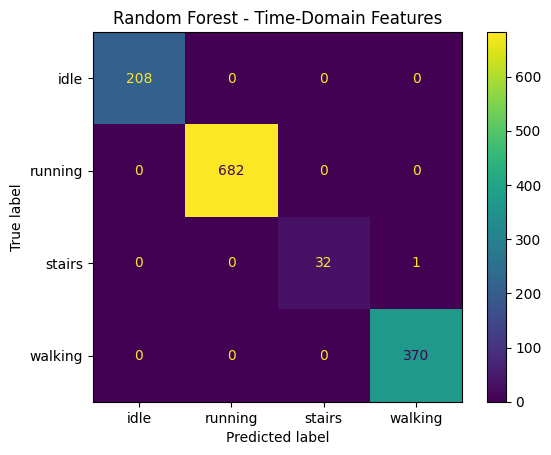

In [28]:
cm_rf_time = confusion_matrix(y_time_test, y_pred_rf_time)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_time,
    display_labels=rf_time_model.classes_
)

disp.plot()
plt.title("Random Forest - Time-Domain Features")
plt.show()

*Порівняла SVM та Random Forest на сирих показниках акселерометра і на time-domain features (mean, std, min, max, median). Обидві моделі показали високі результати. Найбільші труднощі виникли з класом stairs, який має найменшу кількість прикладів. Для SVM використання time-domain features підвищило recall класу stairs з 0.45 до 0.70 та F1-score з 0.61 до 0.79. Для Random Forest покращення було ще краще: recall зріс з 0.06 до 0.97, а F1-score — з 0.11 до 0.98. На confusion matrix dblyj, що на сирих даних Random Forest переважно помилково відносив stairs до walking, а вже при time-domain features така помилка лише одна.*